In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [87]:
# Load cleaned dataset
df = pd.read_csv(r"C:\Users\hemal\OneDrive\Desktop\Python Hackhathon\team9_PyCoders_PythonHackathon_MAY2026\cleaned_data.csv")

DESCRIPTIVE ANALYSIS QUESTIONS

1. Relationship Between Steps and Calories Burned

Reasoning

Physical activity directly affects calorie expenditure. This analysis helps identify whether higher daily steps lead to higher calorie burn.

Why This Analysis is Important

Helps understand patient activity behavior
Useful for fitness and health monitoring
Can support lifestyle improvement recommendations

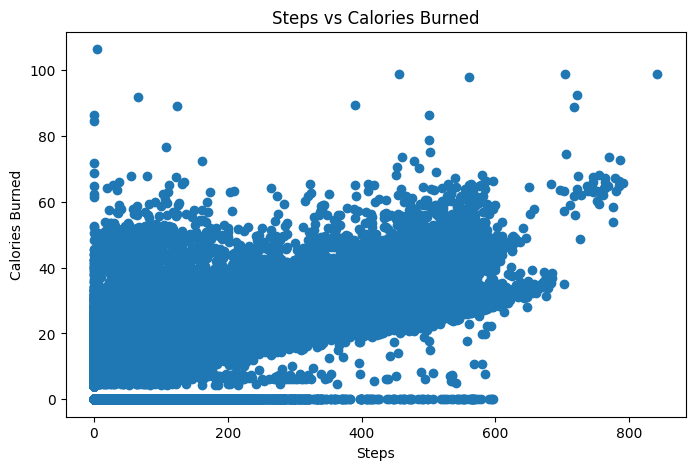

In [88]:
plt.figure(figsize=(8,5))
plt.scatter(df['steps'], df['calories'])
plt.xlabel('Steps')
plt.ylabel('Calories Burned')
plt.title('Steps vs Calories Burned')
plt.show()

Insight Example

Patients with higher step counts generally burned more calories.

2. Average Glucose Level by Gender

Reasoning

Analyzing glucose levels by gender helps identify whether there are differences in glucose patterns between male and female patients.

Why This Analysis is Important

Supports demographic-based health analysis
Helps identify risk groups
Useful for personalized healthcare planning

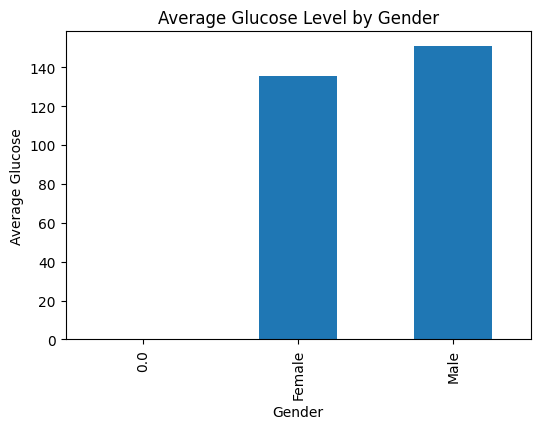

In [89]:
avg_glucose_gender = df.groupby('Gender')['glucose'].mean()

avg_glucose_gender.plot(kind='bar', figsize=(6,4))
plt.ylabel('Average Glucose')
plt.title('Average Glucose Level by Gender')
plt.show()

Insight Example

One gender group may show slightly higher average glucose levels compared to others.

3. Heart Rate Distribution Analysis

Reasoning

Heart rate distribution helps understand the overall cardiovascular condition and variability among patients.

Why This Analysis is Important

Detects abnormal heart rate ranges
Helps identify patient health conditions
Useful for monitoring physical stress and activity

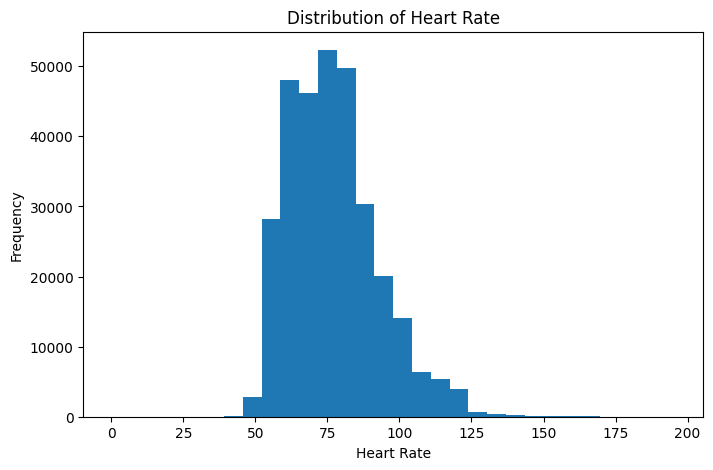

In [90]:
plt.figure(figsize=(8,5))
plt.hist(df['heart_rate'], bins=30)
plt.xlabel('Heart Rate')
plt.ylabel('Frequency')
plt.title('Distribution of Heart Rate')
plt.show()

Insight Example

Most patients had heart rates concentrated within a normal range.

5. Average Steps by Age Group

Reasoning

Different age groups may have different physical activity levels.

Why This Analysis is Important

Helps understand activity trends by age
Useful for fitness tracking and healthcare planning
Supports targeted wellness programs

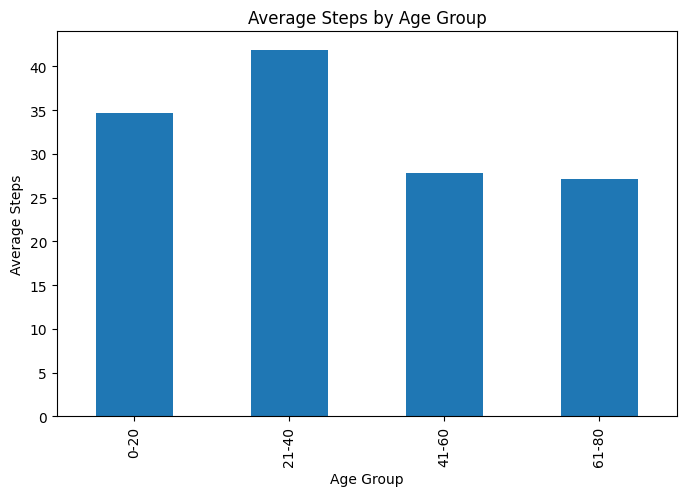

In [91]:
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20', '21-40', '41-60', '61-80', '81-100']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

avg_steps = df.groupby('Age_Group')['steps'].mean()

avg_steps.plot(kind='bar', figsize=(8,5))
plt.xlabel('Age Group')
plt.ylabel('Average Steps')
plt.title('Average Steps by Age Group')
plt.show()

Insight Example

Younger age groups may show higher average step counts compared to older patients.

PRESCRIPTIVE ANALYSIS QUESTIONS

1. How Can Patients Reduce High Glucose Levels?

Reasoning

Patients with high glucose levels may benefit from increased activity and better sleep management.

Why This Analysis is Important

Supports diabetes management
Helps improve patient health outcomes
Enables preventive healthcare recommendations

In [92]:
high_glucose = df[df['glucose'] > 180]

print(high_glucose[['glucose', 'steps', 'Sleep Quality (1-10)']].head())

    glucose  steps  Sleep Quality (1-10)
28   183.67    0.0                   6.8
29   191.33    0.0                   6.8
30   199.00    0.0                   6.8
31   206.33   28.0                   6.8
32   213.67   30.0                   6.8


Recommendation

Encourage patients with high glucose levels to increase physical activity and improve sleep quality.

2. Which Patients Need Better Sleep Management?

Reasoning

Poor sleep quality may affect glucose stability and heart rate.

Why This Analysis is Important
Helps identify patients at health risk
Supports sleep improvement programs
Useful for preventive healthcare strategies

In [93]:
poor_sleep = df[df['Sleep Quality (1-10)'] < 5]
print(poor_sleep[['Patient_ID', 'glucose', 'heart_rate']].head())

      Patient_ID  glucose  heart_rate
15192  HUPA0002P    86.00       65.39
15193  HUPA0002P    82.00       64.27
15194  HUPA0002P    78.00       68.16
15195  HUPA0002P    74.00       63.64
15196  HUPA0002P    76.67       65.49


Recommendation

Provide sleep improvement guidance for patients with poor sleep quality.

3. How Can Physical Activity Be Improved for Low-Step Patients?

Reasoning

Patients with low step counts may have sedentary lifestyles that impact overall health.

Why This Analysis is Important

Encourages healthier lifestyles
Helps reduce obesity and diabetes risks
Supports wellness initiatives

In [94]:
low_activity = df[df['steps'] < 1000]

print(low_activity[['Patient_ID', 'steps', 'calories']].head())

  Patient_ID  steps  calories
0  HUPA0023P    8.0     15.04
1  HUPA0023P    0.0      8.32
2  HUPA0023P    0.0      7.58
3  HUPA0023P    0.0      7.34
4  HUPA0023P    0.0      7.58


Recommendation

Encourage daily walking goals and regular physical activity.

4. Which Patients May Require Glucose Monitoring Alerts?

Reasoning

Patients with highly fluctuating glucose levels may need frequent monitoring.

Why This Analysis is Important

Helps avoid severe glucose conditions
Supports real-time monitoring systems
Improves patient safety

In [95]:
glucose_variation = df.groupby('Patient_ID')['glucose'].std()

high_variation = glucose_variation.sort_values(ascending=False)

print(high_variation.head())

Patient_ID
HUPA0006P    84.736090
HUPA0004P    83.020748
HUPA0016P    79.837163
HUPA0020P    78.785654
HUPA0007P    78.656652
Name: glucose, dtype: float64


Recommendation

Implement glucose alert systems for patients with high glucose variability.

5. How Can Healthcare Providers Improve Heart Health?

Reasoning

Abnormal heart rates may indicate cardiovascular stress or low fitness levels.

Why This Analysis is Important

Helps identify high-risk patients
Supports cardiac monitoring
Useful for preventive treatment planning

In [96]:
abnormal_hr = df[(df['heart_rate'] > 120) | (df['heart_rate'] < 50)]

print(abnormal_hr[['Patient_ID', 'heart_rate', 'steps']].head())

    Patient_ID  heart_rate  steps
88   HUPA0023P       49.55    0.0
89   HUPA0023P       49.72    0.0
112  HUPA0023P       49.38    0.0
113  HUPA0023P       48.16    0.0
120  HUPA0023P       49.31    0.0


Recommendation

Recommend regular cardiovascular checkups and activity monitoring.

6. Which Age Groups Need More Health Interventions?

Reasoning

Older age groups may experience lower activity levels and higher glucose levels.

Why This Analysis is Important

Helps healthcare providers focus on vulnerable groups
Supports targeted healthcare programs
Useful for patient care planning

In [97]:
age_analysis = df.groupby('Age_Group')[['glucose', 'steps']].mean()

print(age_analysis)

              glucose      steps
Age_Group                       
0-20       143.677664  34.664698
21-40      161.232452  41.905820
41-60      133.238830  27.837306
61-80      146.378866  27.157083


Recommendation

Develop specialized wellness programs for higher-risk age groups.

7. How Can Carb Intake Be Better Managed?

Reasoning

Higher carbohydrate intake can influence glucose spikes.

Why This Analysis is Important

Supports nutrition planning
Helps improve glucose management
Useful for dietary recommendations

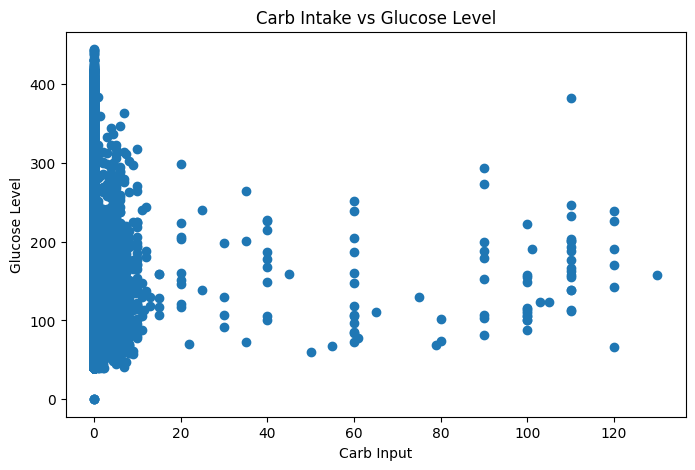

In [98]:
plt.figure(figsize=(8,5))
plt.scatter(df['carb_input'], df['glucose'])
plt.xlabel('Carb Input')
plt.ylabel('Glucose Level')
plt.title('Carb Intake vs Glucose Level')
plt.show()

Recommendation

Recommend balanced carbohydrate intake and nutritional guidance.